# Multi-Bearing Full Life-Cycle Evaluation
This notebook visualizes the anomaly scores (MSE) of a single trained model across multiple bearing datasets (B01, B02, B03, B04, B05). 
It helps in understanding how well the model generalizes to different bearings and tracks their degradation trends.

In [19]:
import os
import sys
import torch
import numpy as np
import matplotlib.pyplot as plt
import yaml
import pandas as pd
from tqdm.auto import tqdm

# Add project root to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.models.mamba import MambaTSOfficial, MambaTSConfig, HybridMambaCNN
from src.data import BearingDataset
from src.evaluation.anomaly_scorer import calculate_anomaly_score
from src.evaluation.metrics import calculate_threshold_pot

DISABLE_STATS_GLOBAL = False

In [20]:
# --- Configuration ---

# mamba_hybrid
# model_path = os.path.join(project_root, "results/models/mamba1_hybrid_best.pth")
# model_path = os.path.join(project_root, "results/models/mamba1_hybrid_small_best.pth")
# model_path = os.path.join(project_root, "results/models/mamba1_hybrid_tiny_best.pth")
model_path = os.path.join(project_root, "results/models/mamba1_hybrid_nano_best.pth")
# model_path = os.path.join(project_root, "results/models/mamba1_hybrid_expanded_best.pth")

# mambats_off
# model_path = os.path.join(project_root, "results/models/mambats_official_best.pth")
# model_path = os.path.join(project_root, "results/models/mambats_official_small_best.pth")
# model_path = os.path.join(project_root, "results/models/mambats_official_tiny_best.pth")
# model_path = os.path.join(project_root, "results/models/mambats_official_nano_best.pth")
# model_path = os.path.join(project_root, "results/models/mambats_official_expanded_best.pth")

# config_path = os.path.join(project_root, "configs/default.yaml")
# config_path = os.path.join(project_root, "configs/small.yaml")
# config_path = os.path.join(project_root, "configs/tiny.yaml")
config_path = os.path.join(project_root, "configs/nano.yaml")
# config_path = os.path.join(project_root, "configs/expanded.yaml")

device = "cuda" if torch.cuda.is_available() else "cpu"

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

lookback = config['data'].get('lookback', 4096)
horizon = config['data'].get('horizon', 1024)
patch_size = config['data'].get('patch_size', 2048)
stride = config['data'].get('stride', 1024)
sampling_rate = config['data'].get('sampling_rate', 128000)
highpass_freq = config['data'].get('highpass_freq', 2000)

SKIP_RATIO = 0  # Standard skip_ratio for the dataset
POT_Q = 1e-3       # POT probability parameter

print(f"Device: {device}")
print(f"Model Path: {model_path}")
print(f"Skip ratio: {SKIP_RATIO*100}%")

Device: cuda
Model Path: /mnt/f/APPS_PJ/mamba-forecast-ad/results/models/mamba1_hybrid_nano_best.pth
Skip ratio: 0%


In [21]:
# --- Load Model ---
def load_model(path, config, device):
    # Trích xuất các tham số chung từ config
    lookback = config['data'].get('lookback', 4096)
    horizon = config['data'].get('horizon', 1024)
    
    # Model patching params (lấy từ mục model trong config)
    patch_size = config['model'].get('patch_size', 64)
    patch_stride = config['model'].get('patch_stride', 32)
    trend_downsample = config['model'].get('trend_downsample', 1) # QUAN TRỌNG: Sửa lỗi mismatch trend_head

    if "hybrid" in path.lower():
        model_full_config = {
            'model': {
                'mamba_version': 1,
                'mamba_d_model': config['model'].get('mamba_d_model', 64), 
                'mamba_n_layer': config['model'].get('mamba_n_layer', 4),
                'mamba_d_state': config['model'].get('mamba_d_state', 16), 
                'mamba_d_conv': config['model'].get('mamba_d_conv', 4), 
                'mamba_expand': config['model'].get('mamba_expand', 2),
                'forecast_len': horizon, 
                'patch_size': patch_size, 
                'stride': patch_stride,
                'trend_downsample': trend_downsample, # Thêm vào để khớp kiến trúc mới
                'in_channels': 2, 
                'lookback': lookback,
                'decomp_kernel': config['model'].get('decomp_kernel', 25), 
                'use_multiscale': True,
            },
            'data': {'patch_size': patch_size, 'stride': patch_stride, 'lookback': lookback}
        }
        model = HybridMambaCNN(model_full_config)
    else:
        mamba_config = MambaTSConfig(
            in_channels=2, 
            lookback=lookback, 
            forecast_len=horizon,
            patch_size=patch_size, 
            stride=patch_stride, 
            d_model=config['model'].get('mamba_d_model', 64), 
            n_layers=config['model'].get('mamba_n_layer', 4)
        )
        model = MambaTSOfficial(mamba_config)
        
    if os.path.exists(path):
        # map_location giúp load model GPU lên CPU nếu cần
        checkpoint = torch.load(path, map_location=device, weights_only=True)
        model.load_state_dict(checkpoint)
        print(f"Model loaded successfully from {path}")
    else:
        print(f"WARNING: Model path {path} not found! Using uninitialized model.")
        
    model.to(device)
    model.eval()
    return model

# Đảm bảo bạn đã load config đúng file (ví dụ configs/small.yaml) trước khi gọi dòng này
model = load_model(model_path, config, device)

Model loaded successfully from /mnt/f/APPS_PJ/mamba-forecast-ad/results/models/mamba1_hybrid_nano_best.pth


In [22]:
# --- Evaluation Function ---
from src.models.mamba import HybridMambaCNN, MambaTSOfficial
from tqdm.notebook import tqdm
import torch.nn as nn
import os
import numpy as np
import torch

def evaluate_bearing(bearing_id, model, device, disable_stats=None):
    # Nếu không truyền tham số, lấy giá trị từ Global
    if disable_stats is None:
        disable_stats = DISABLE_STATS_GLOBAL
        
    processed_dir = os.path.join(project_root, "data/processed", bearing_id)
    if not os.path.exists(processed_dir):
        print(f"Skip {bearing_id}: path not found.")
        return None
    
    dataset = BearingDataset(
        processed_dir, lookback, horizon, stride, split='test', 
        normalize=False, skip_ratio=SKIP_RATIO, train_ratio=0.0
    )
    
    all_files = dataset.files
    n_total = len(all_files)
    start_idx = int(n_total * dataset.skip_ratio)
    eval_files = all_files[start_idx:]
    
    # 1. Chuẩn bị bộ lọc High-pass ngoài vòng lặp (Tối ưu hiệu năng)
    b, a = None, None
    if highpass_freq > 0:
        from scipy import signal as scipy_signal
        nyq = 0.5 * sampling_rate
        normal_cutoff = highpass_freq / nyq
        b, a = scipy_signal.butter(4, normal_cutoff, btype='high', analog=False)
    
    is_hybrid = isinstance(model, HybridMambaCNN)
    num_stats = 8 if is_hybrid else 6
    results = {'indices': [], 'mse': [], 'rms': []}
    
    print(f"Processing {bearing_id} (Stats Disabled: {disable_stats})")

    with torch.no_grad():
        for i, f_name in enumerate(tqdm(eval_files, desc=bearing_id)):
            actual_idx = i + start_idx
            f_path = os.path.join(processed_dir, f_name)
            signal_data = torch.load(f_path, map_location='cpu', weights_only=True)
            
            # 2. Áp dụng lọc High-pass cho toàn bộ file trước khi cắt cửa sổ
            if b is not None:
                from scipy import signal as scipy_signal
                sig_filtered = scipy_signal.lfilter(b, a, signal_data.numpy(), axis=1)
                signal_data = torch.from_numpy(sig_filtered.copy()).float()
            
            win_starts = np.linspace(0, signal_data.shape[1] - lookback - horizon, 3, dtype=int)
            file_errs = []
            
            for start in win_starts:
                x = signal_data[:, start:start+lookback]
                y = signal_data[:, start+lookback:start+lookback+horizon]
                
                x_gpu = x.unsqueeze(0).to(device)
                y_gpu = y.unsqueeze(0).to(device)
                
                # Tính toán stats
                mean = x.mean(dim=-1, keepdim=True)
                std = x.std(dim=-1, keepdim=True)
                rms = torch.sqrt(torch.mean(x**2, dim=-1, keepdim=True))
                peak = torch.max(torch.abs(x), dim=-1, keepdim=True)[0]
                z = (x - mean) / (std + 1e-8)
                skew = torch.mean(z**3, dim=-1, keepdim=True)
                kurt = torch.mean(z**4, dim=-1, keepdim=True)
                crest = peak / (rms + 1e-8)
                shape = rms / (torch.mean(torch.abs(x), dim=-1, keepdim=True) + 1e-8)
                
                # Gom stats
                all_stats_list = [mean, std, rms, peak, skew, kurt, crest, shape]
                
                # 3. Xử lý VÔ HIỆU HÓA stats nếu cần
                if disable_stats:
                    all_stats_list[2] = torch.zeros_like(mean) # RMS về 0
                    all_stats_list[5] = torch.zeros_like(mean) # Kurtosis về 0
                
                stats_tensor = torch.cat(all_stats_list[:num_stats], dim=-1).unsqueeze(0).to(device)
                
                # Dự báo
                if is_hybrid:
                    y_pred = model(x_gpu, stats=stats_tensor.unsqueeze(1))
                else:
                    y_pred = model(x_gpu, oc=stats_tensor.mean(dim=1))
                
                mse = calculate_anomaly_score(y_gpu, y_pred, metric='mse', normalized=False).item()
                file_errs.append(mse)
            
            results['indices'].append(actual_idx)
            results['mse'].append(np.mean(file_errs))
            results['rms'].append(dataset.file_rms[f_name])
            
    return results

In [23]:
# --- Run Loop ---
bearing_ids = ['B01', 'B02', 'B03', 'B04', 'B05']
# bearing_ids = ['B01', 'B04']
all_results = {}

for b_id in bearing_ids:
    res = evaluate_bearing(b_id, model, device)
    if res:
        all_results[b_id] = res

Processing B01 (Stats Disabled: False)


B01:   0%|          | 0/377 [00:00<?, ?it/s]

Processing B02 (Stats Disabled: False)


B02:   0%|          | 0/1116 [00:00<?, ?it/s]

Processing B03 (Stats Disabled: False)


B03:   0%|          | 0/614 [00:00<?, ?it/s]

Processing B04 (Stats Disabled: False)


B04:   0%|          | 0/1114 [00:00<?, ?it/s]

Processing B05 (Stats Disabled: False)


B05:   0%|          | 0/572 [00:00<?, ?it/s]

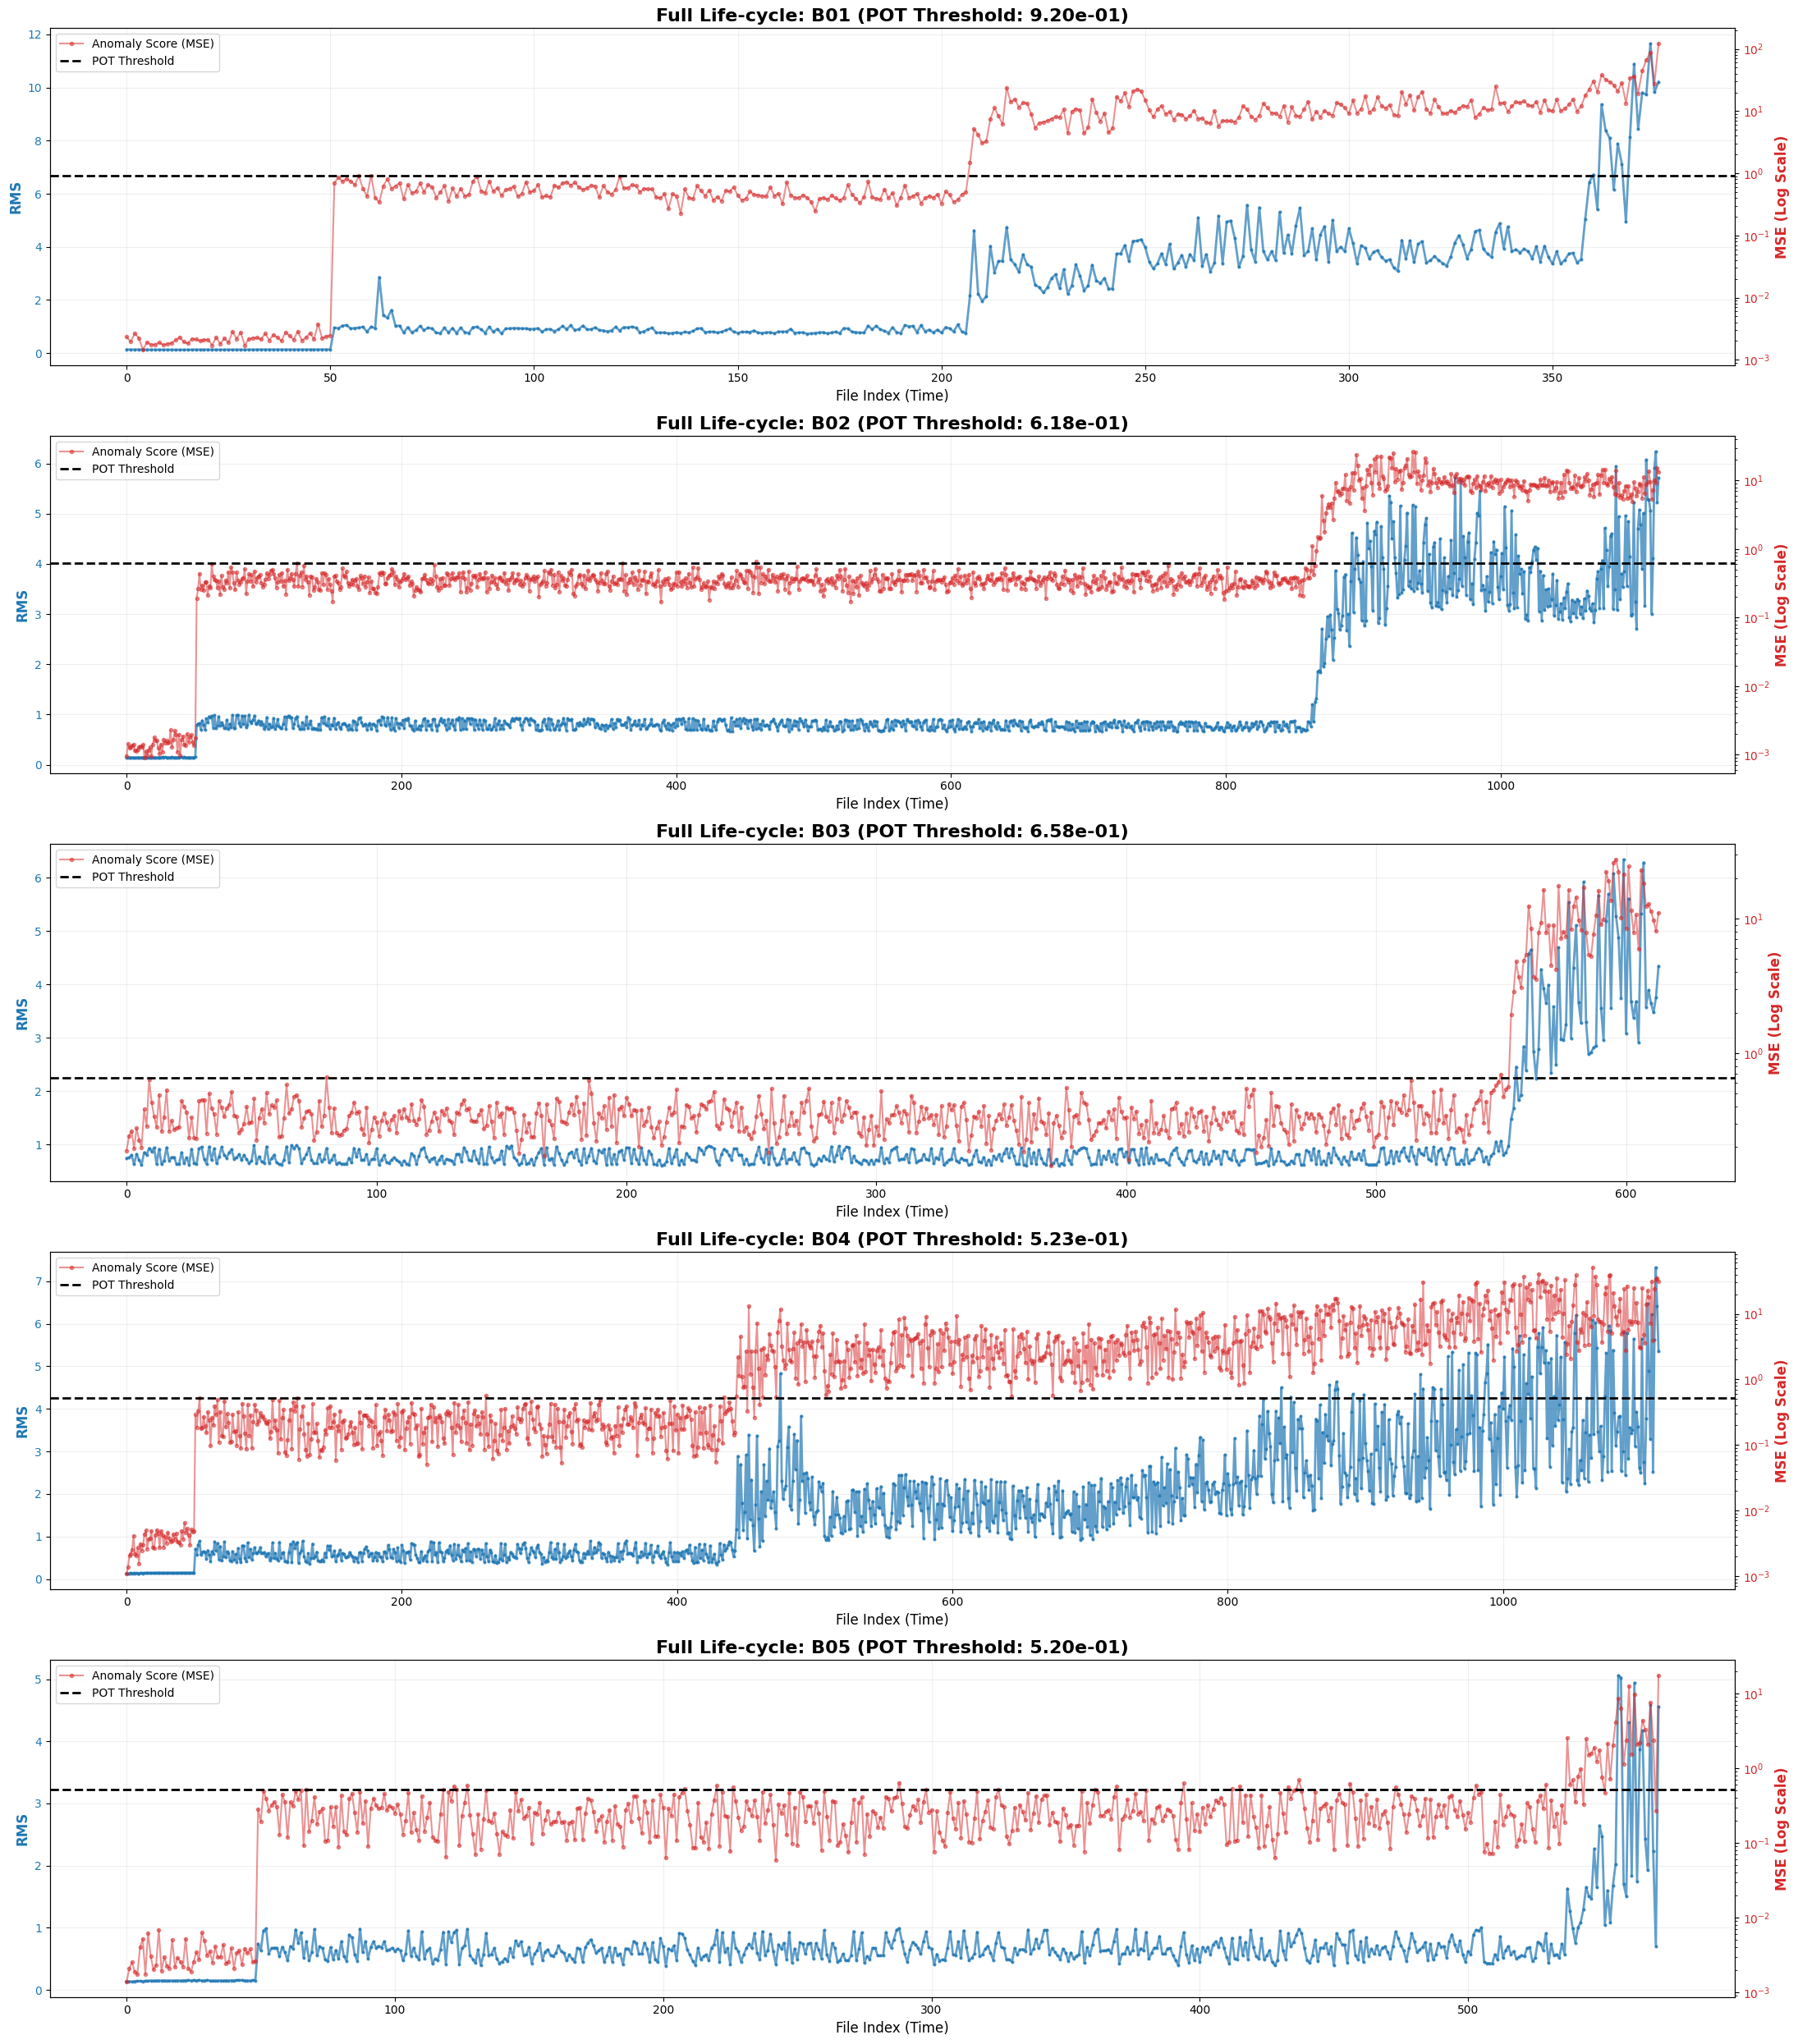

In [24]:
# --- Plotting (Cập nhật để phóng to và nhìn rõ hơn) ---
n_bearings = len(all_results)
if n_bearings > 0:
    # 1. Tăng figsize width từ 15 lên 22 để hình rộng hơn
    fig, axes = plt.subplots(n_bearings, 1, figsize=(22, 5 * n_bearings), sharex=False)
    if n_bearings == 1: axes = [axes]
    
    for i, b_id in enumerate(all_results.keys()):
        res = all_results[b_id]
        ax = axes[i]
        
        scores = np.array(res['mse'])
        indices = np.array(res['indices'])
        rms_vals = np.array(res['rms'])
        
        # Ngưỡng POT
        n_init = max(5, int(len(scores) * 0.2))
        threshold = calculate_threshold_pot(scores[:n_init], q=POT_Q)
        
        ax.set_title(f"Full Life-cycle: {b_id} (POT Threshold: {threshold:.2e})", fontsize=16, fontweight='bold')
        
        # RMS (Trục trái) - Thêm marker để nhìn rõ từng điểm khi phóng to
        color_rms = 'tab:blue'
        ax.plot(indices, rms_vals, color=color_rms, label='RMS', linewidth=2, marker='.', markersize=4, alpha=0.7)
        ax.set_ylabel('RMS', color=color_rms, fontsize=12, fontweight='bold')
        ax.tick_params(axis='y', labelcolor=color_rms)
        
        # MSE (Trục phải)
        ax_twin = ax.twinx()
        color_mse = 'tab:red'
        ax_twin.plot(indices, scores, color=color_mse, alpha=0.5, label='Anomaly Score (MSE)', marker='o', markersize=3)
        ax_twin.axhline(y=threshold, color='black', linestyle='--', linewidth=2, label=f'POT Threshold')
        ax_twin.set_ylabel('MSE (Log Scale)', color=color_mse, fontsize=12, fontweight='bold')
        ax_twin.tick_params(axis='y', labelcolor=color_mse)
        ax_twin.set_yscale('log')
        
        # --- PHÓNG TO GIAI ĐOẠN CUỐI ---
        # Bạn có thể uncomment dòng dưới đây để chủ động zoom vào đoạn cuối của mỗi bearing
        # ax.set_xlim(left=indices[int(len(indices)*0.7)]) 
        
        ax.grid(True, which="both", ls="-", alpha=0.2)
        ax.set_xlabel('File Index (Time)', fontsize=12)
        ax_twin.legend(loc='upper left', fontsize=10)
        
    plt.tight_layout()
    plt.show()


In [33]:
def evaluate_bearing_v2(bearing_id, model, device, disable_stats=None):
    # Nếu không truyền tham số, lấy giá trị từ Global
    if disable_stats is None:
        disable_stats = DISABLE_STATS_GLOBAL
        
    processed_dir = os.path.join(project_root, "data/processed", bearing_id)
    if not os.path.exists(processed_dir):
        print(f"Skip {bearing_id}: path not found.")
        return None
    
    dataset = BearingDataset(
        processed_dir, lookback, horizon, stride, split='test', 
        normalize=False, skip_ratio=SKIP_RATIO, train_ratio=0.0
    )
    
    all_files = dataset.files
    n_total = len(all_files)
    start_idx = int(n_total * dataset.skip_ratio)
    eval_files = all_files[start_idx:]
    
    # 1. Chuẩn bị bộ lọc High-pass ngoài vòng lặp (Tối ưu hiệu năng)
    b, a = None, None
    if highpass_freq > 0:
        from scipy import signal as scipy_signal
        nyq = 0.5 * sampling_rate
        normal_cutoff = highpass_freq / nyq
        b, a = scipy_signal.butter(4, normal_cutoff, btype='high', analog=False)
    
    is_hybrid = isinstance(model, HybridMambaCNN)
    num_stats = 8 if is_hybrid else 6
    results = {'indices': [], 'mse': [], 'rms': [], 'kurtosis': []}
    
    print(f"Processing {bearing_id} (Stats Disabled: {disable_stats}) [V2 - Smooth Trend]")

    with torch.no_grad():
        for i, f_name in enumerate(tqdm(eval_files, desc=bearing_id)):
            actual_idx = i + start_idx
            f_path = os.path.join(processed_dir, f_name)
            signal_data = torch.load(f_path, map_location='cpu', weights_only=True)
            
            # 2. Áp dụng lọc High-pass cho toàn bộ file trước khi cắt cửa sổ
            if b is not None:
                from scipy import signal as scipy_signal
                sig_filtered = scipy_signal.lfilter(b, a, signal_data.numpy(), axis=1)
                signal_data = torch.from_numpy(sig_filtered.copy()).float()
            
            # V2: Lấy 10 cửa sổ mẫu để tính trung bình lỗi mịn hơn
            win_starts = np.linspace(0, signal_data.shape[1] - lookback - horizon, 10, dtype=int)
            file_errs = []
            file_kurtosis = []
            
            for start in win_starts:
                x = signal_data[:, start:start+lookback]
                y = signal_data[:, start+lookback:start+lookback+horizon]
                
                x_gpu = x.unsqueeze(0).to(device)
                y_gpu = y.unsqueeze(0).to(device)
                
                # Tính toán stats
                mean = x.mean(dim=-1, keepdim=True)
                std = x.std(dim=-1, keepdim=True)
                rms = torch.sqrt(torch.mean(x**2, dim=-1, keepdim=True))
                peak = torch.max(torch.abs(x), dim=-1, keepdim=True)[0]
                z = (x - mean) / (std + 1e-8)
                skew = torch.mean(z**3, dim=-1, keepdim=True)
                kurt = torch.mean(z**4, dim=-1, keepdim=True)
                crest = peak / (rms + 1e-8)
                shape = rms / (torch.mean(torch.abs(x), dim=-1, keepdim=True) + 1e-8)

                file_kurtosis.append(kurt.mean().item())

                # Gom stats
                all_stats_list = [mean, std, rms, peak, skew, kurt, crest, shape]
                
                # Xử lý VÔ HIỆU HÓA stats nếu cần
                if disable_stats:
                    all_stats_list[2] = torch.zeros_like(mean)
                    all_stats_list[5] = torch.zeros_like(mean)
                
                stats_tensor = torch.cat(all_stats_list[:num_stats], dim=-1).unsqueeze(0).to(device)
                
                y_pred = model(x_gpu, stats=stats_tensor.unsqueeze(1)) if is_hybrid else model(x_gpu, oc=stats_tensor.mean(dim=1))
                mse = calculate_anomaly_score(y_gpu, y_pred, metric='mse', normalized=False).item()
                file_errs.append(mse)
            
            results['indices'].append(actual_idx)
            results['mse'].append(np.mean(file_errs))
            results['rms'].append(dataset.file_rms[f_name])
            results['kurtosis'].append(np.mean(file_kurtosis))
            
    return results


In [34]:
# --- 1. Chạy lại đánh giá cho toàn bộ 5 vòng bi ---
bearing_ids = ['B01', 'B02', 'B03', 'B04', 'B05']
all_results_v2 = {}

for b_id in bearing_ids:
    # Gọi hàm v2 (hàm bạn vừa tắt RMS/Kurtosis)
    res = evaluate_bearing_v2(b_id, model, device)
    if res:
        all_results_v2[b_id] = res
    else:
        print(f"Lỗi: Không tìm thấy dữ liệu cho {b_id}")

Processing B01 (Stats Disabled: False) [V2 - Smooth Trend]


B01:   0%|          | 0/377 [00:00<?, ?it/s]

Processing B02 (Stats Disabled: False) [V2 - Smooth Trend]


B02:   0%|          | 0/1116 [00:00<?, ?it/s]

Processing B03 (Stats Disabled: False) [V2 - Smooth Trend]


B03:   0%|          | 0/614 [00:00<?, ?it/s]

Processing B04 (Stats Disabled: False) [V2 - Smooth Trend]


B04:   0%|          | 0/1114 [00:00<?, ?it/s]

Processing B05 (Stats Disabled: False) [V2 - Smooth Trend]


B05:   0%|          | 0/572 [00:00<?, ?it/s]

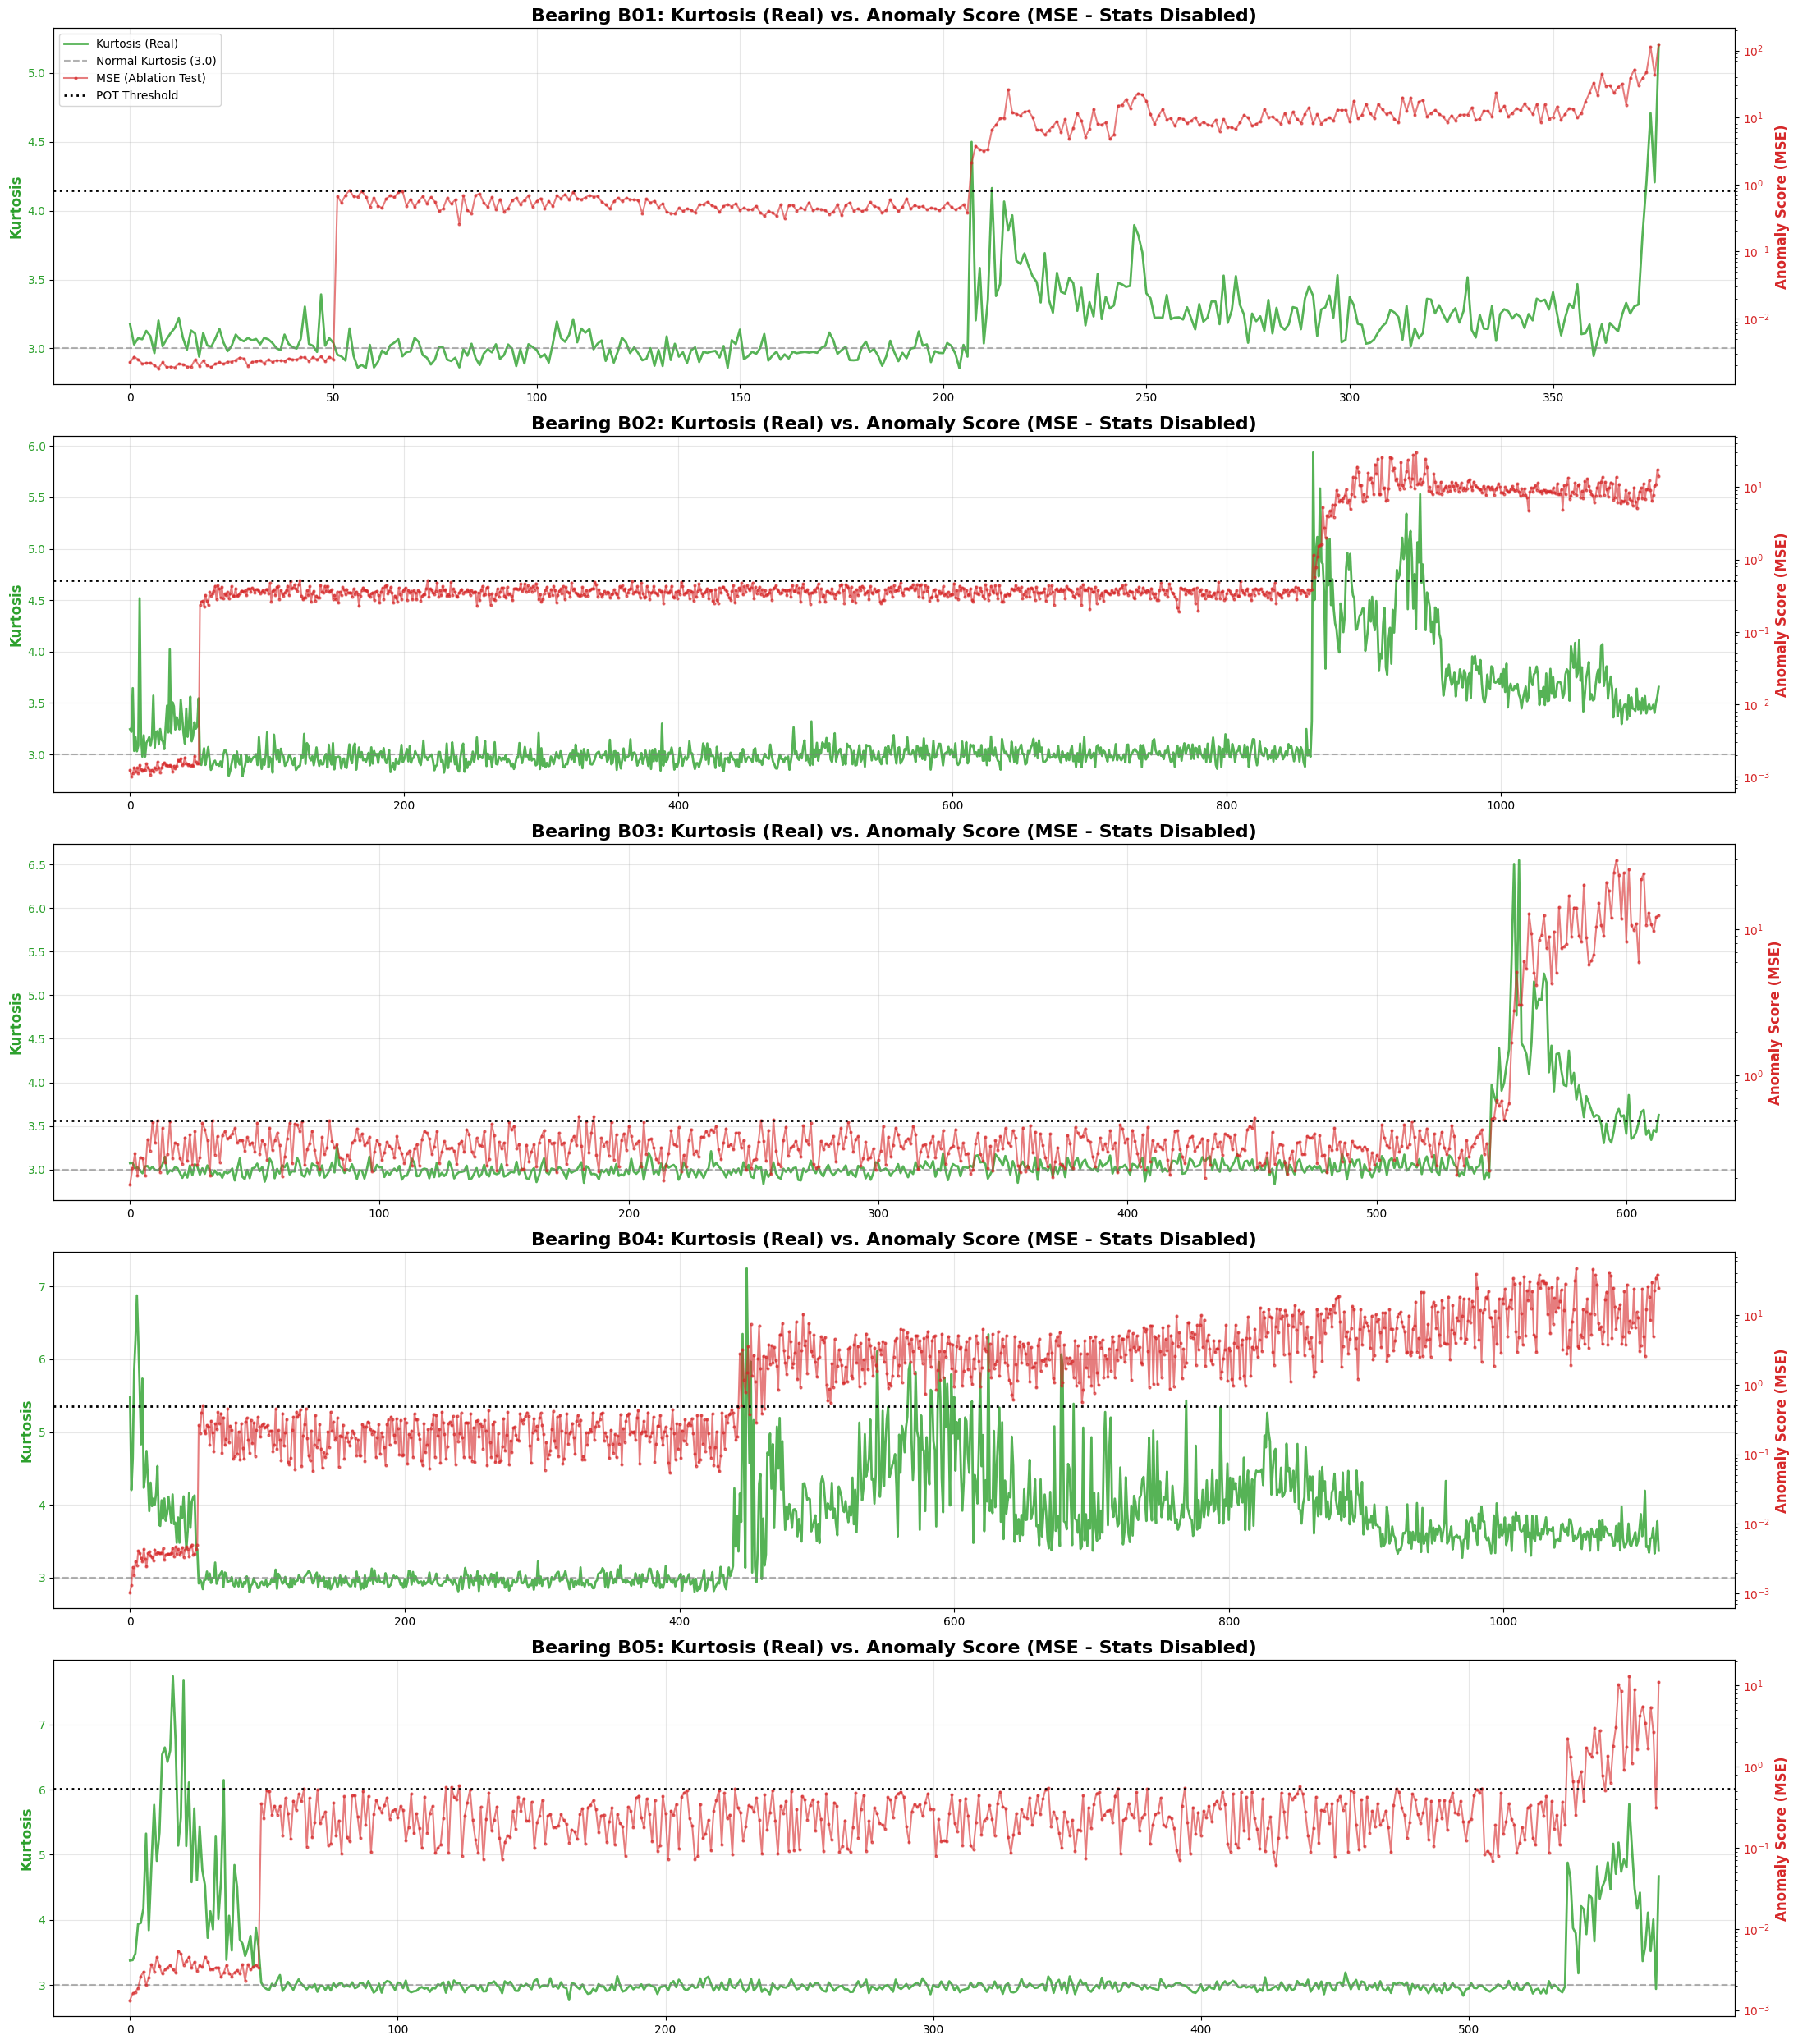

In [35]:
# --- 2. Vẽ biểu đồ Full vòng bi với kích thước phóng to ---
n_res = len(all_results_v2)
if n_res > 0:
    # Tăng chiều rộng lên 22 để nhìn rõ độ trễ của MSE so với Kurtosis/RMS
    fig, axes = plt.subplots(n_res, 1, figsize=(22, 5 * n_res), sharex=False)
    if n_res == 1: axes = [axes]

    for i, (b_id, res) in enumerate(all_results_v2.items()):
        ax1 = axes[i]
        
        # Trục trái: Kurtosis (Dữ liệu thật để đối chiếu)
        color_kurt = 'tab:green'
        ax1.plot(res['indices'], res['kurtosis'], color=color_kurt, linewidth=2, label='Kurtosis (Real)', alpha=0.8)
        ax1.set_ylabel('Kurtosis', color=color_kurt, fontsize=12, fontweight='bold')
        ax1.tick_params(axis='y', labelcolor=color_kurt)
        ax1.grid(True, alpha=0.3)
        ax1.set_title(f"Bearing {b_id}: Kurtosis (Real) vs. Anomaly Score (MSE - Stats Disabled)", fontsize=16, fontweight='bold')
        
        # Đường ngưỡng Kurtosis lý thuyết
        ax1.axhline(y=3.0, color='gray', linestyle='--', alpha=0.6, label='Normal Kurtosis (3.0)')
        
        # Trục phải: Anomaly Score (MSE) - Lúc này MSE không còn biết RMS/Kurt là bao nhiêu
        ax2 = ax1.twinx()
        color_mse = 'tab:red'
        ax2.plot(res['indices'], res['mse'], color=color_mse, linewidth=1.5, alpha=0.6, label='MSE (Ablation Test)', marker='o', markersize=2)
        ax2.set_ylabel('Anomaly Score (MSE)', color=color_mse, fontsize=12, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor=color_mse)
        ax2.set_yscale('log') 
        
        # Ngưỡng POT dựa trên MSE mới
        thresh = calculate_threshold_pot(np.array(res['mse'])[:int(len(res['mse'])*0.2)], q=POT_Q)
        ax2.axhline(y=thresh, color='black', linestyle=':', linewidth=2, label=f'POT Threshold')

        # Gom legend
        if i == 0:
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu để vẽ. Vui lòng kiểm tra lại đường dẫn data/processed.")
